# Mol3D — Graph Diameter & Hasse Diameter Analysis

Two structural-complexity metrics per molecule, both **diameters** (longest shortest path), computed on 4 different graphs (test split only, 2,000 molecules):

- **atom** — plain atom-bond graph diameter (`graph_diameter`, from `dataset_per_molecule.npz`)
- **ct6** — CT's 6-relation cell complex, **atom-restricted** Hasse diameter: longest shortest path between two *atoms*, but bond/ring cells can be used as shortcuts en route (`atom_hasse_diameter`, reused from `../mol3d_fullerene/mol3d_atom_hasse_test_only.npz` — same global mol3d index, test-only)
- **cin** — CIN's message-passing graph, same atom-restricted construction (`cin_atom_hasse_diameter`, from `hasse_graph_cin_per_molecule.npz`)
- **cinpp** — CIN++'s message-passing graph, same atom-restricted construction (`cinpp_atom_hasse_diameter`)

Being atom-restricted, all three (`ct6`/`cin`/`cinpp`) are **guaranteed ≤ `atom`'s graph_diameter** (same endpoints, strictly more edges available to route through) — a ratio ≤ 1.0 always, unlike the unrestricted Hasse diameter used elsewhere in this repo (which can occasionally exceed the atom-only diameter via a peripheral bond/ring cell).

**SchNet** is included in the Overview/scatter sections below (`results_mol3d_schnet.json`, non-tuned — no hp-tuned run exists), but is **excluded** from the "GNN vs. Other Architectures" section: SchNet doesn't message-pass over the bond/ring graph at all (continuous-filter convolutions over 3D distances instead), so it has no `ct6`/`cin`/`cinpp`-analogous graph type of its own to plot there.

In [49]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = Path('results')

In [50]:
FILES = {
    'CT-coords': 'results_mol3d_ct_coords_hptuned.json',
    'CT-simple': 'results_mol3d_ct_simple_hptuned.json',
    'CT-full':   'results_mol3d_ct_full_hptuned.json',
    'GCN':       'results_mol3d_gcn_hptuned.json',
    'GAT':       'results_mol3d_gat_hptuned.json',
    'GIN':       'results_mol3d_gin_hptuned.json',
    'CIN':       'results_mol3d_cin_hptuned.json',
    'CINpp':     'results_mol3d_cinpp_hptuned.json',
    'SchNet':    'results_mol3d_schnet.json',
}

data = {}
for label, fname in FILES.items():
    p = RESULTS_DIR / fname
    if p.exists():
        with open(p) as f:
            data[label] = json.load(f)
    else:
        print(f'Missing: {fname}')

print(f'Loaded {len(data)} result files: {list(data.keys())}')

Loaded 9 result files: ['CT-coords', 'CT-simple', 'CT-full', 'GCN', 'GAT', 'GIN', 'CIN', 'CINpp', 'SchNet']


In [51]:
COLORS = {
    'CT':     '#4C72B0',
    'GCN':    '#DD8452',
    'GAT':    '#55A868',
    'GIN':    '#C44E52',
    'CINpp':  '#937860',
    'CIN':    '#8172B2',
    'SchNet': '#64B5CD',
}

def model_color(label):
    for prefix, c in COLORS.items():
        if label.startswith(prefix):
            return c
    return 'gray'

model_labels = list(data.keys())
n_models = len(model_labels)
MODEL_COLOR = {lbl: model_color(lbl) for lbl in model_labels}

def per_molecule_err(d):
    err_by_idx = {}
    for run in d['runs']:
        for p in run['predictions']:
            err_by_idx.setdefault(p['index'], []).append(abs(p['pred'] - p['true']))
    return {k: float(np.mean(v)) for k, v in err_by_idx.items()}

err_maps = {lbl: per_molecule_err(data[lbl]) for lbl in model_labels}
for lbl in model_labels:
    print(f'{lbl:10s} n_molecules={len(err_maps[lbl])}')

CT-coords  n_molecules=2000
CT-simple  n_molecules=2000
CT-full    n_molecules=2000
GCN        n_molecules=2000
GAT        n_molecules=2000
GIN        n_molecules=2000
CIN        n_molecules=2000
CINpp      n_molecules=2000
SchNet     n_molecules=2000


In [52]:
PREFIXES = ('atom', 'ct6', 'cin', 'cinpp')

atom_npz = np.load('dataset_per_molecule.npz')
atom_pos = {int(i): k for k, i in enumerate(atom_npz['index'])}
graph_diameter = atom_npz['graph_diameter'].astype(float)

ct6_npz = np.load('../mol3d_fullerene/mol3d_atom_hasse_test_only.npz')
ct6_pos = {int(i): k for k, i in enumerate(ct6_npz['index'])}
ct6_diameter = ct6_npz['atom_hasse_diameter'].astype(float)

cin_npz = np.load('hasse_graph_cin_per_molecule.npz')
cin_pos = {int(i): k for k, i in enumerate(cin_npz['index'])}
cin_diameter = cin_npz['cin_atom_hasse_diameter'].astype(float)
cinpp_diameter = cin_npz['cinpp_atom_hasse_diameter'].astype(float)

POS = {'atom': atom_pos, 'ct6': ct6_pos, 'cin': cin_pos, 'cinpp': cin_pos}
ARR = {'atom': graph_diameter, 'ct6': ct6_diameter, 'cin': cin_diameter, 'cinpp': cinpp_diameter}

def get_diameter(prefix, idx):
    pos = POS[prefix].get(idx)
    return None if pos is None else float(ARR[prefix][pos])

def diam_array(prefix, ids):
    pos, arr = POS[prefix], ARR[prefix]
    return np.array([arr[pos[i]] for i in ids if i in pos], dtype=float)

# ct6/cin/cinpp are test-only (2,000) by construction; atom's file covers the
# full 10k pool, so restrict everything to the shared test population.
common_ids = sorted(set.intersection(*(set(POS[p]) for p in PREFIXES)))
print(f'Common test molecules across all 4 graphs: {len(common_ids):,}')

for p in PREFIXES:
    arr = diam_array(p, common_ids)
    print(f'{p:6s}  n={len(arr):,}  min={arr.min():.0f}  max={arr.max():.0f}  mean={arr.mean():.2f}')

Common test molecules across all 4 graphs: 2,000
atom    n=2,000  min=4  max=17  mean=9.79
ct6     n=2,000  min=4  max=17  mean=9.09
cin     n=2,000  min=4  max=17  mean=9.72
cinpp   n=2,000  min=4  max=17  mean=9.66


## Overview of Statistics

Each molecule contributes one diameter value per graph. `ct6`/`cin`/`cinpp` are test-only by construction (2,000); `atom` covers the full 10k pool but is looked up per test molecule via `atom_pos`.

In [53]:
rows = []
for p in PREFIXES:
    arr = diam_array(p, common_ids)
    rows.append({
        'graph': p, 'dataset_mean': arr.mean(), 'dataset_std': arr.std(),
        'dataset_min': arr.min(), 'dataset_max': arr.max(), 'n_valid': len(arr),
    })

overview_df = pd.DataFrame(rows).set_index('graph')
display(overview_df.style.format(precision=2).background_gradient(subset=['dataset_mean'], cmap='RdYlGn_r'))

,dataset_mean,dataset_std,dataset_min,dataset_max,n_valid
graph,,,,,
atom,9.79,1.85,4.00,17.00,2000
ct6,9.09,1.85,4.00,17.00,2000
cin,9.72,1.88,4.00,17.00,2000
cinpp,9.66,1.85,4.00,17.00,2000


### Diameter distribution, by graph

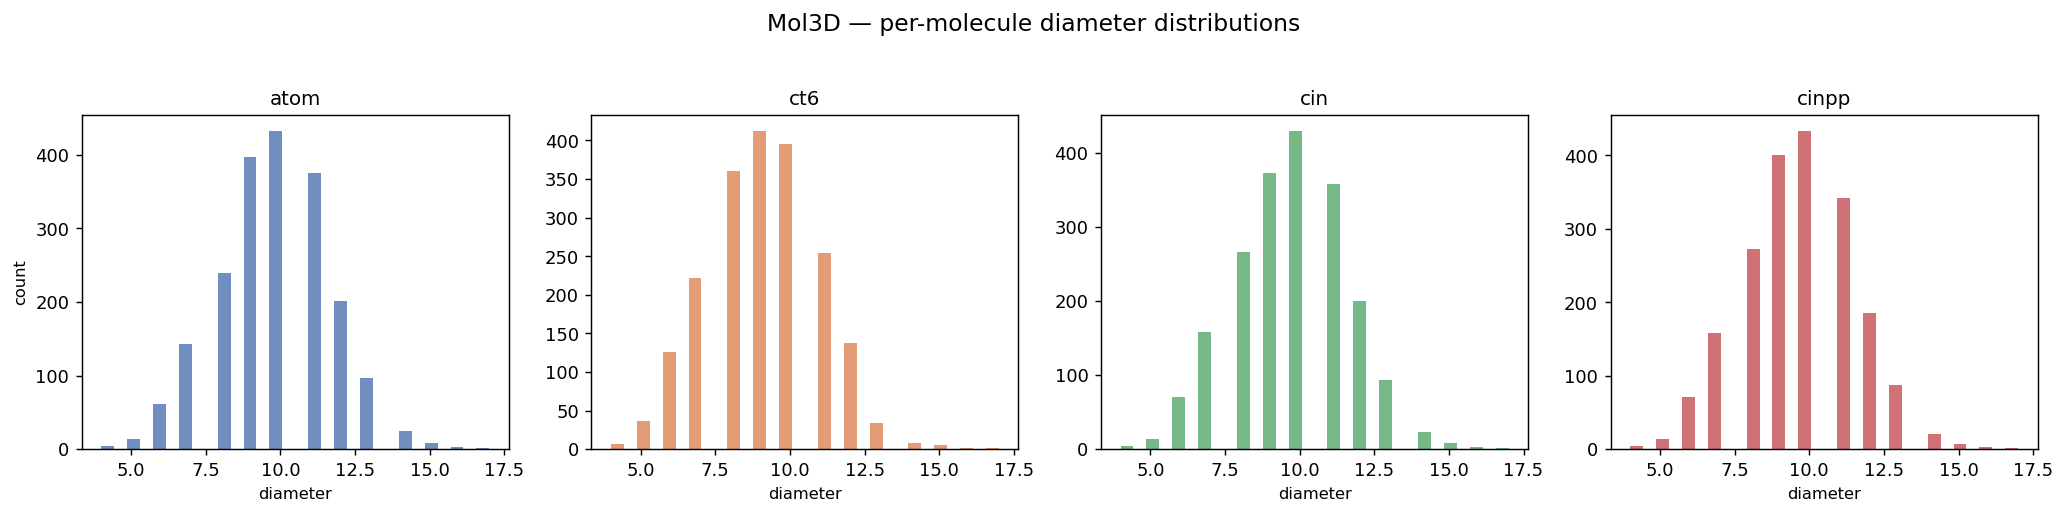

In [54]:
GRAPH_COLOR = {'atom': '#4C72B0', 'ct6': '#DD8452', 'cin': '#55A868', 'cinpp': '#C44E52'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for col, p in enumerate(PREFIXES):
    ax = axes[col]
    ax.hist(diam_array(p, common_ids), bins=30, color=GRAPH_COLOR[p], alpha=0.8)
    ax.set_title(p, fontsize=11)
    ax.set_xlabel('diameter', fontsize=9)
    if col == 0:
        ax.set_ylabel('count', fontsize=9)

plt.suptitle('Mol3D — per-molecule diameter distributions', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## Diameter vs. Model Error — Every Model, Per Graph Type

For each of the 4 graphs, one row of scatter plots — every model shown side by side, sharing the same x-axis (that graph's diameter for the molecule) against that model's own per-molecule absolute test error. Dashed line = linear fit.

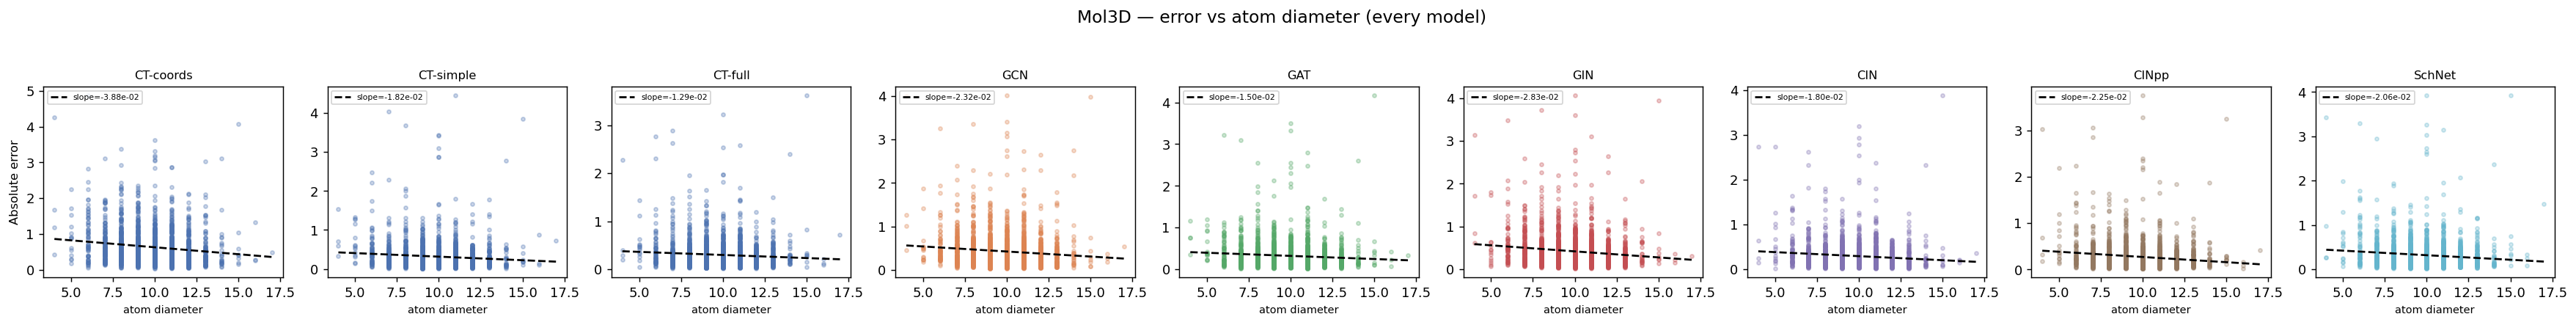

In [55]:
def plot_err_vs_diameter(prefix):
    diam_pos, diam_arr = POS[prefix], ARR[prefix]
    fig, axes = plt.subplots(1, n_models, figsize=(3.0 * n_models, 3.2), squeeze=False)
    axes = axes[0]
    for col, lbl in enumerate(model_labels):
        ax = axes[col]
        color = MODEL_COLOR[lbl]
        err_by_idx = err_maps[lbl]
        idxs = np.array(sorted(i for i in err_by_idx if i in diam_pos))
        x = diam_arr[[diam_pos[i] for i in idxs]]
        y = np.array([err_by_idx[i] for i in idxs])
        ax.scatter(x, y, color=color, alpha=0.3, s=8, rasterized=True)
        if len(x) >= 2 and np.ptp(x) > 0:
            coeffs = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_line, np.polyval(coeffs, x_line), color='black', linewidth=1.5,
                    linestyle='--', label=f'slope={coeffs[0]:.2e}')
            ax.legend(fontsize=6, loc='upper left')
        ax.set_title(lbl, fontsize=9)
        if col == 0:
            ax.set_ylabel('Absolute error', fontsize=9)
        ax.set_xlabel(f'{prefix} diameter', fontsize=8)
    plt.suptitle(f'Mol3D — error vs {prefix} diameter (every model)', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

plot_err_vs_diameter('atom')

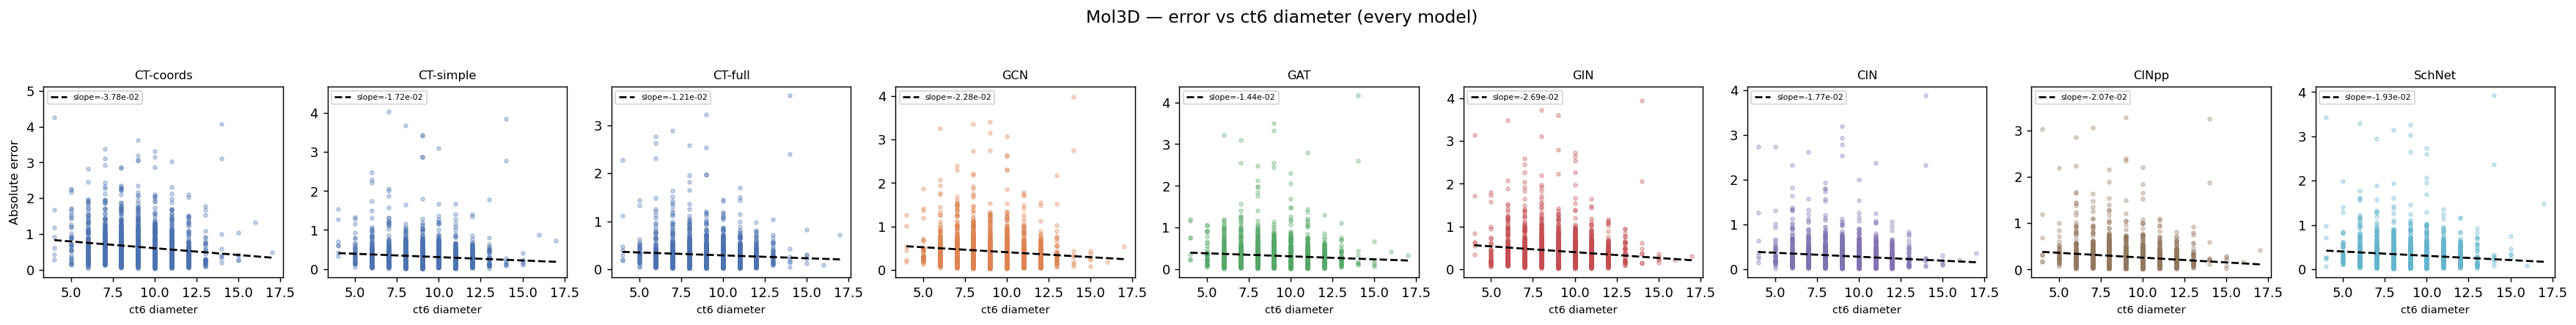

In [56]:
plot_err_vs_diameter('ct6')

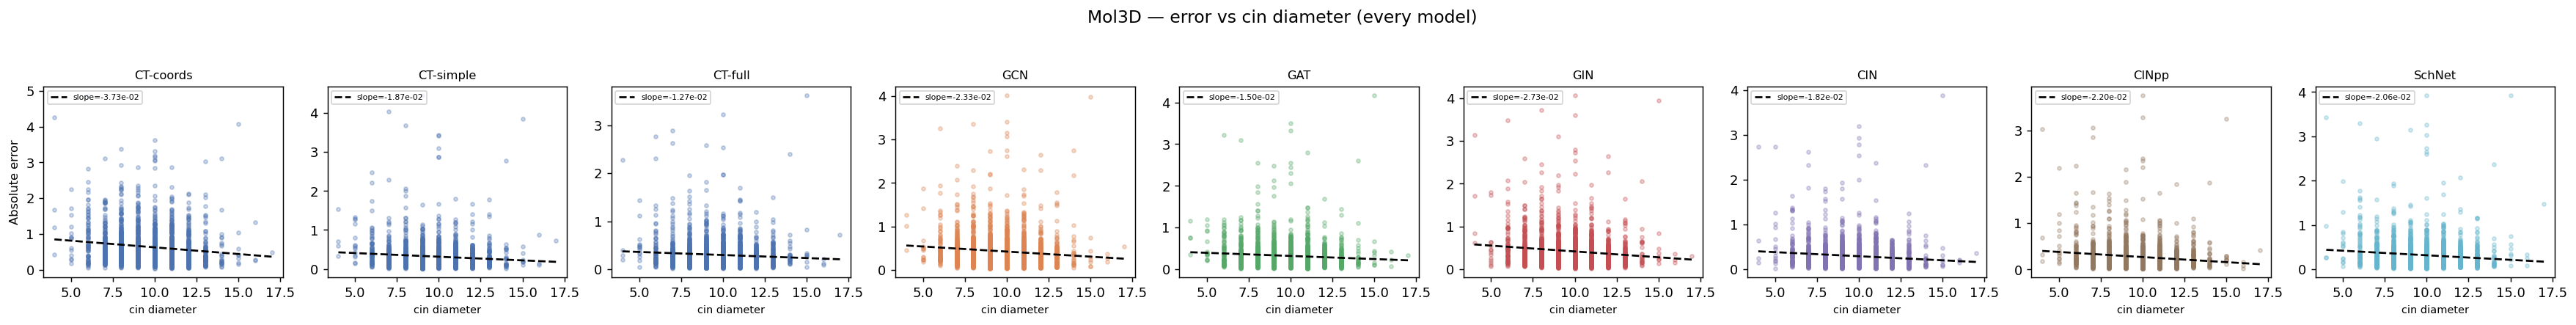

In [57]:
plot_err_vs_diameter('cin')

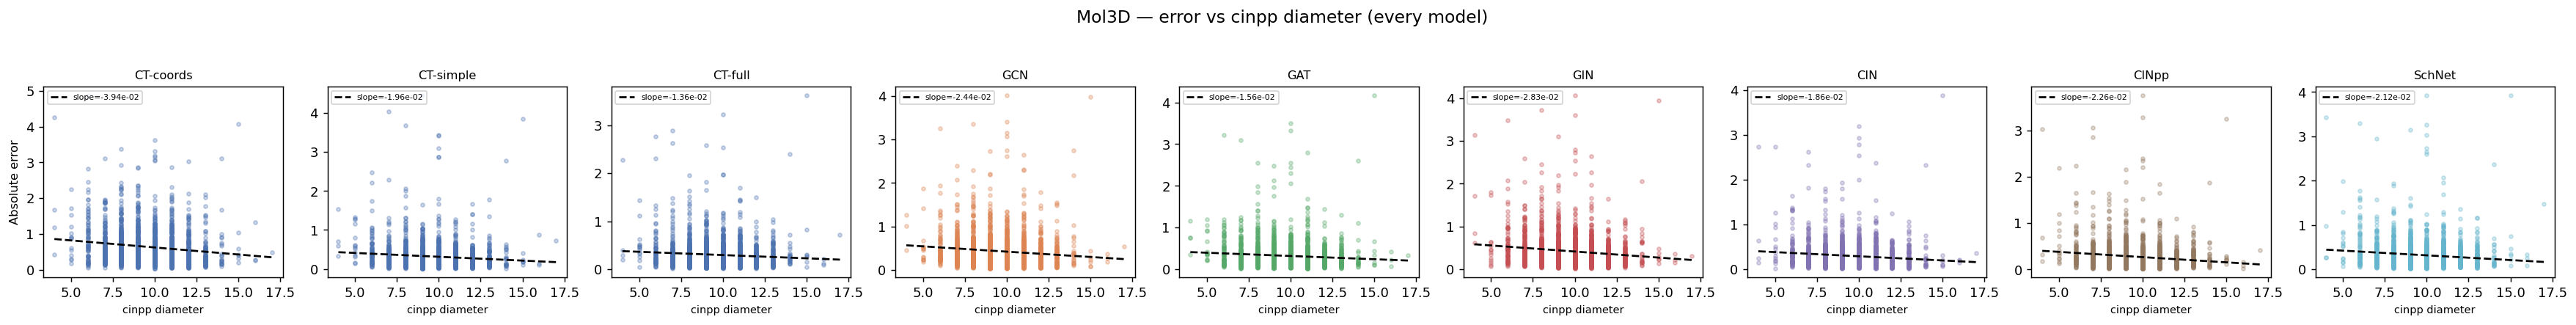

In [58]:
plot_err_vs_diameter('cinpp')

## GNN vs. Other Architectures — Diameter by Outcome

For every non-GNN model (CT variants, CIN, CINpp — **SchNet excluded**, see intro), split test molecules into two sets: **gnn_beats** (at least one of GCN/GAT/GIN has strictly lower error than this model on that molecule) vs. **model_beats** (this model's error was ≤ every GNN's there — it held its own). Same construction as `analyze_commute_time.ipynb`'s GNN-comparison sections (identical `err_maps`, so identical sets).

Four panels per model: **plain graph diameter** (atom) by outcome, **this model's own** Hasse diameter (`ct6` for CT variants, `cin` for CIN, `cinpp` for CINpp) by outcome, the **difference** `hasse - atom` diameter by outcome (always ≤ 0, since Hasse is atom-restricted), and the **ratio** `hasse/atom` diameter by outcome. Same 3-color scheme as the commute-time notebook: gray = overlap, red = `gnn_beats`-only excess, blue = `model_beats`-only excess (density-normalized histograms, stacked).

In [59]:
GNN_MODELS = [lbl for lbl in model_labels if lbl in ('GCN', 'GAT', 'GIN')]
NON_GNN_MODELS = [lbl for lbl in model_labels if lbl not in GNN_MODELS and lbl != 'SchNet']
# SchNet excluded: it has no ct6/cin/cinpp-analogous graph type of its own (see intro).

def model_prefix(label):
    """Which graph type this model's own diameter comes from."""
    if label.startswith('CT'):
        return 'ct6'
    if label.startswith('CINpp'):
        return 'cinpp'
    if label.startswith('CIN'):
        return 'cin'
    raise ValueError(f'no prefix mapping for {label}')

def build_gnn_beats_set(model_label):
    """molecule indices present in model_label's AND every GNN's err_maps.
    gnn_beats = indices where the best GNN's error is strictly lower than
    model_label's error there; model_beats = the rest of the common set
    (model_label's error was <= every GNN's, i.e. it held its own)."""
    common = set(err_maps[model_label])
    for g in GNN_MODELS:
        common &= set(err_maps[g])
    beats = {k for k in common
             if min(err_maps[g][k] for g in GNN_MODELS) < err_maps[model_label][k]}
    return beats, common - beats

gnn_beats_sets = {m: build_gnn_beats_set(m) for m in NON_GNN_MODELS}
for m in NON_GNN_MODELS:
    gnn_beats, model_beats = gnn_beats_sets[m]
    print(f'{m:12s}  gnn_beats={len(gnn_beats)}  model_beats={len(model_beats)}')

CT-coords     gnn_beats=1755  model_beats=245
CT-simple     gnn_beats=1283  model_beats=717
CT-full       gnn_beats=1223  model_beats=777
CIN           gnn_beats=1272  model_beats=728
CINpp         gnn_beats=1124  model_beats=876


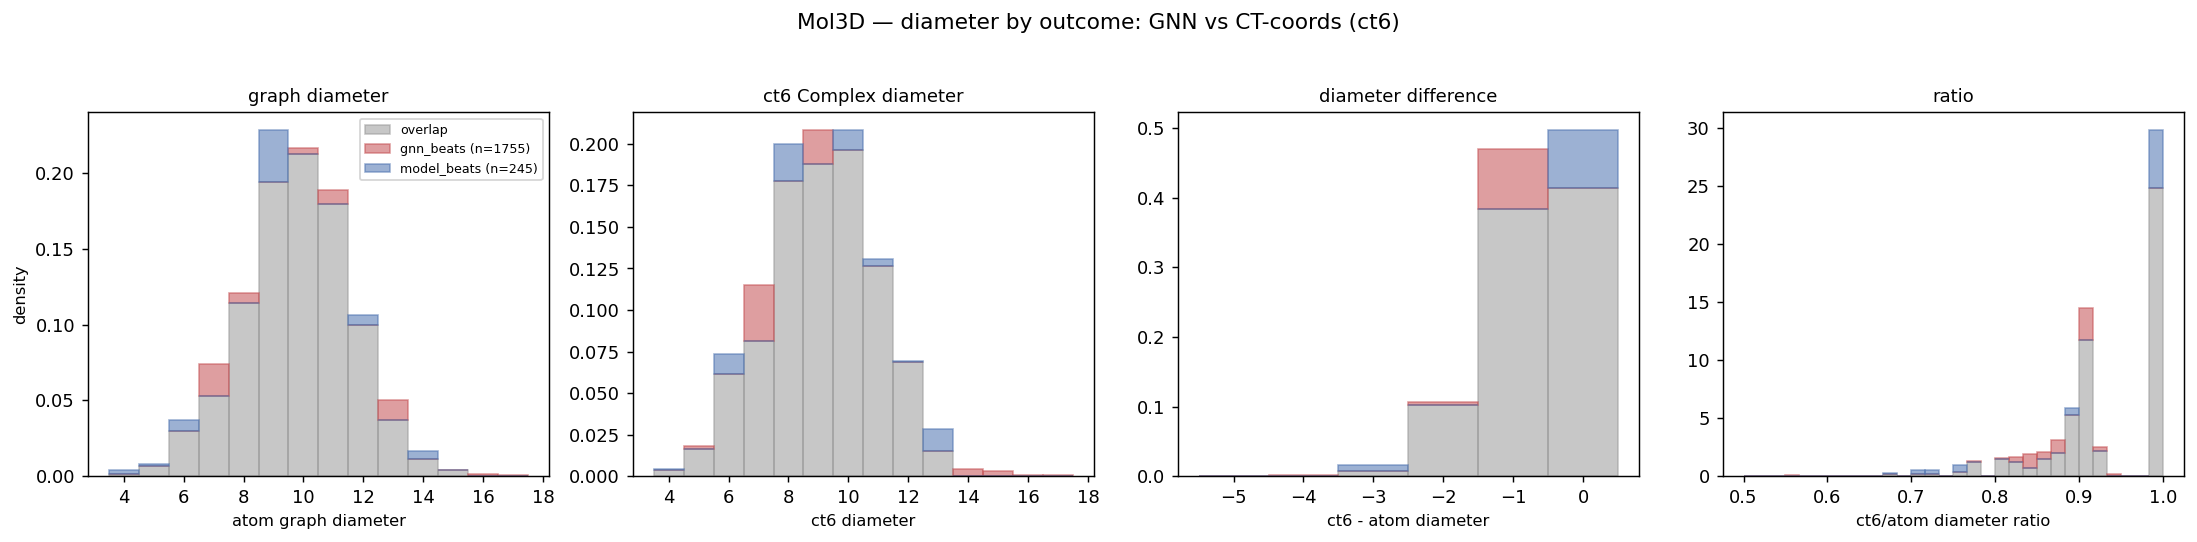

In [65]:
OUTCOME_COLOR = {'gnn_beats': '#C44E52', 'model_beats': '#4C72B0'}
OVERLAP_COLOR = '#999999'

def _diam_vals(prefix, keys):
    pos, arr = POS[prefix], ARR[prefix]
    vals = [arr[pos[k]] for k in keys if k in pos]
    return np.array(vals, dtype=float)

def _diff_vals(prefix, keys):
    apos, aarr = POS['atom'], ARR['atom']
    ppos, parr = POS[prefix], ARR[prefix]
    vals = [parr[ppos[k]] - aarr[apos[k]] for k in keys if k in apos and k in ppos]
    return np.array(vals, dtype=float)

def _ratio_vals(prefix, keys):
    apos, aarr = POS['atom'], ARR['atom']
    ppos, parr = POS[prefix], ARR[prefix]
    vals = []
    for k in keys:
        if k not in apos or k not in ppos:
            continue
        d = aarr[apos[k]]
        n = parr[ppos[k]]
        if d == 0:
            continue
        vals.append(n / d)
    return np.array(vals, dtype=float)

def _stacked_hist(ax, vals_a, vals_b, label_a, label_b, color_a, color_b, bins=30, integer=False):
    """Overlap (gray) as base, per-bin excess of whichever group is taller
    stacked on top in that group's own color. Bars are translucent with a
    solid-color outline so overlapping regions stay readable. integer=True
    uses one bin per integer value so bars touch with no gaps except where a
    diameter value truly has zero count -- used for the 3 integer-valued
    panels (diameter has no fractional values); the ratio panel stays
    continuous (default 30 bins)."""
    all_vals = np.concatenate([vals_a, vals_b])
    if integer:
        lo, hi = int(np.floor(all_vals.min())), int(np.ceil(all_vals.max()))
        edges = np.arange(lo - 0.5, hi + 1.5, 1.0)
    else:
        edges = np.histogram_bin_edges(all_vals, bins=bins)
    h_a, _ = np.histogram(vals_a, bins=edges, density=True)
    h_b, _ = np.histogram(vals_b, bins=edges, density=True)
    overlap = np.minimum(h_a, h_b)
    excess_a = h_a - overlap
    excess_b = h_b - overlap
    width = edges[1] - edges[0]
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, overlap, width=width, color=OVERLAP_COLOR, alpha=0.55,
           edgecolor=OVERLAP_COLOR, linewidth=0.9, label='overlap')
    ax.bar(centers, excess_a, width=width, bottom=overlap, color=color_a, alpha=0.55,
           edgecolor=color_a, linewidth=0.9, label=f'{label_a} (n={len(vals_a)})')
    ax.bar(centers, excess_b, width=width, bottom=overlap, color=color_b, alpha=0.55,
           edgecolor=color_b, linewidth=0.9, label=f'{label_b} (n={len(vals_b)})')

def plot_diameter_hist_by_outcome(model_label):
    p = model_prefix(model_label)
    gnn_beats, model_beats = gnn_beats_sets[model_label]
    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    ax = axes[0]
    _stacked_hist(ax, _diam_vals('atom', gnn_beats), _diam_vals('atom', model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'],
                  integer=True)
    ax.set_xlabel('atom graph diameter', fontsize=9)
    ax.set_ylabel('density', fontsize=9)
    ax.set_title('graph diameter', fontsize=10)
    ax.legend(fontsize=7)

    ax = axes[1]
    _stacked_hist(ax, _diam_vals(p, gnn_beats), _diam_vals(p, model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'],
                  integer=True)
    ax.set_xlabel(f'{p} diameter', fontsize=9)
    ax.set_title(f'{p} Complex diameter', fontsize=10)

    ax = axes[2]
    _stacked_hist(ax, _diff_vals(p, gnn_beats), _diff_vals(p, model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'],
                  integer=True)
    ax.set_xlabel(f'{p} - atom diameter', fontsize=9)
    ax.set_title('diameter difference', fontsize=10)

    ax = axes[3]
    _stacked_hist(ax, _ratio_vals(p, gnn_beats), _ratio_vals(p, model_beats),
                  'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'])
    ax.set_xlabel(f'{p}/atom diameter ratio', fontsize=9)
    ax.set_title('ratio', fontsize=10)

    plt.suptitle(f'Mol3D — diameter by outcome: GNN vs {model_label} ({p})', fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()

plot_diameter_hist_by_outcome('CT-coords')

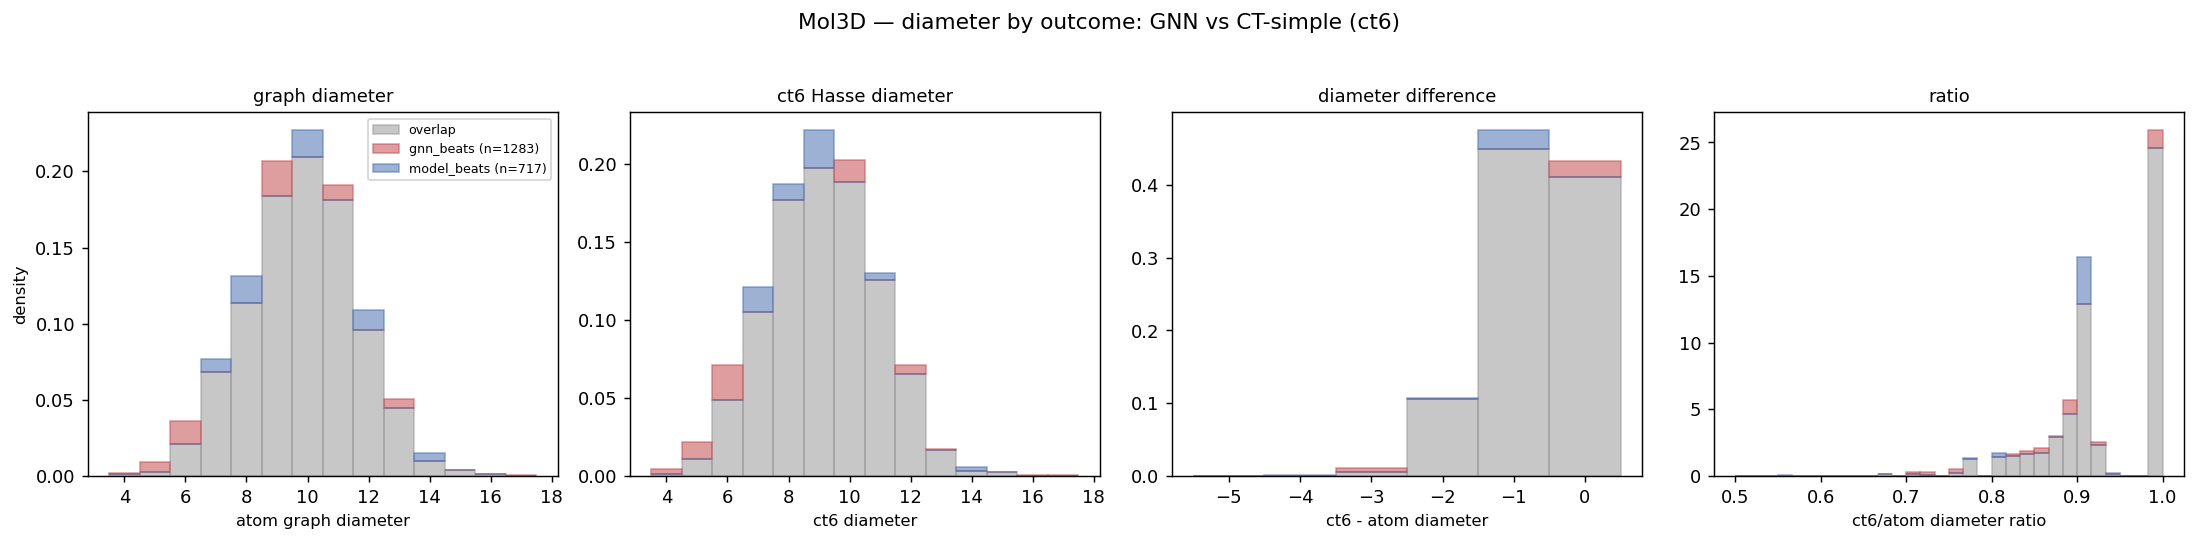

In [61]:
plot_diameter_hist_by_outcome('CT-simple')

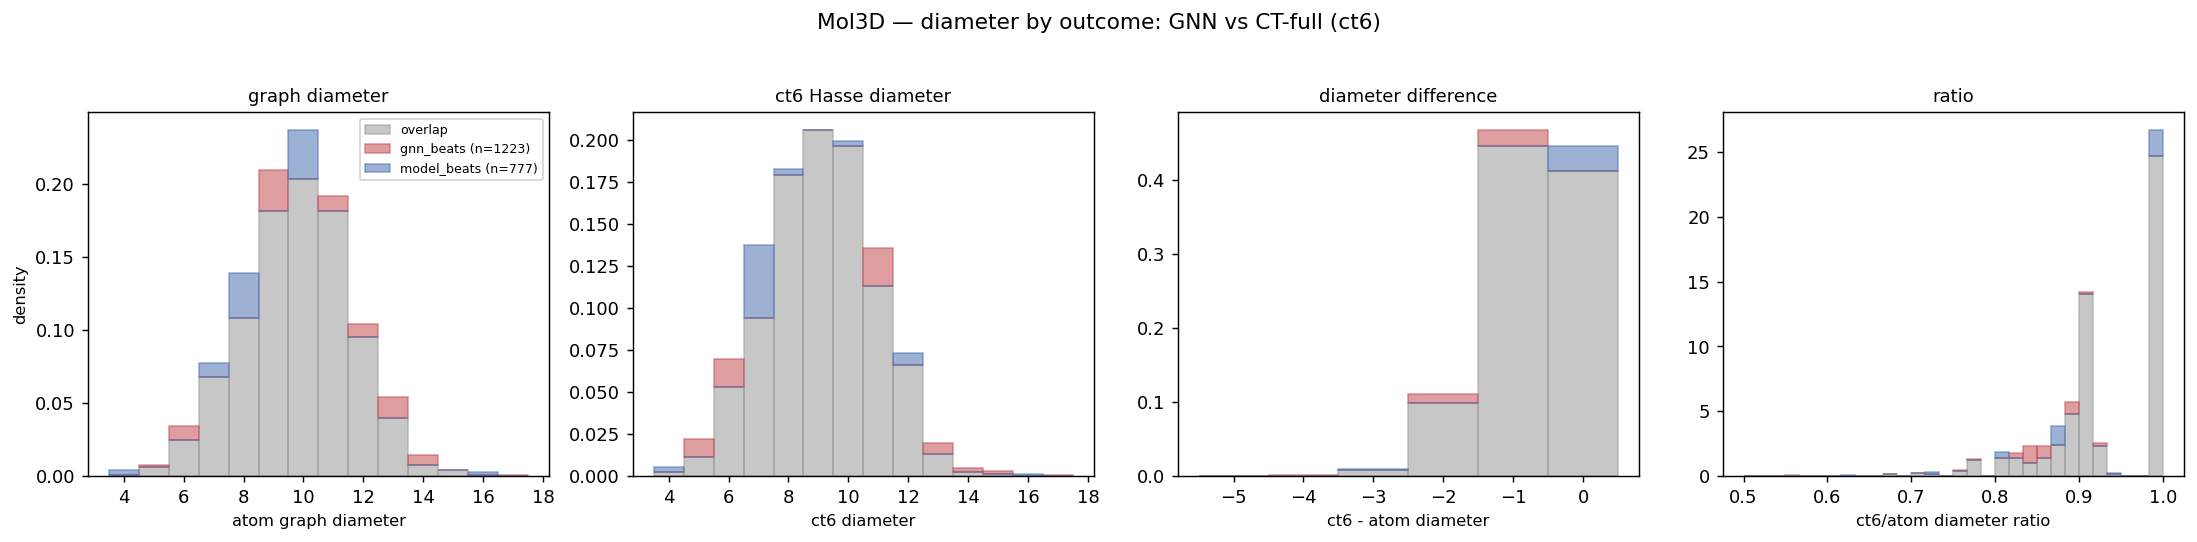

In [62]:
plot_diameter_hist_by_outcome('CT-full')

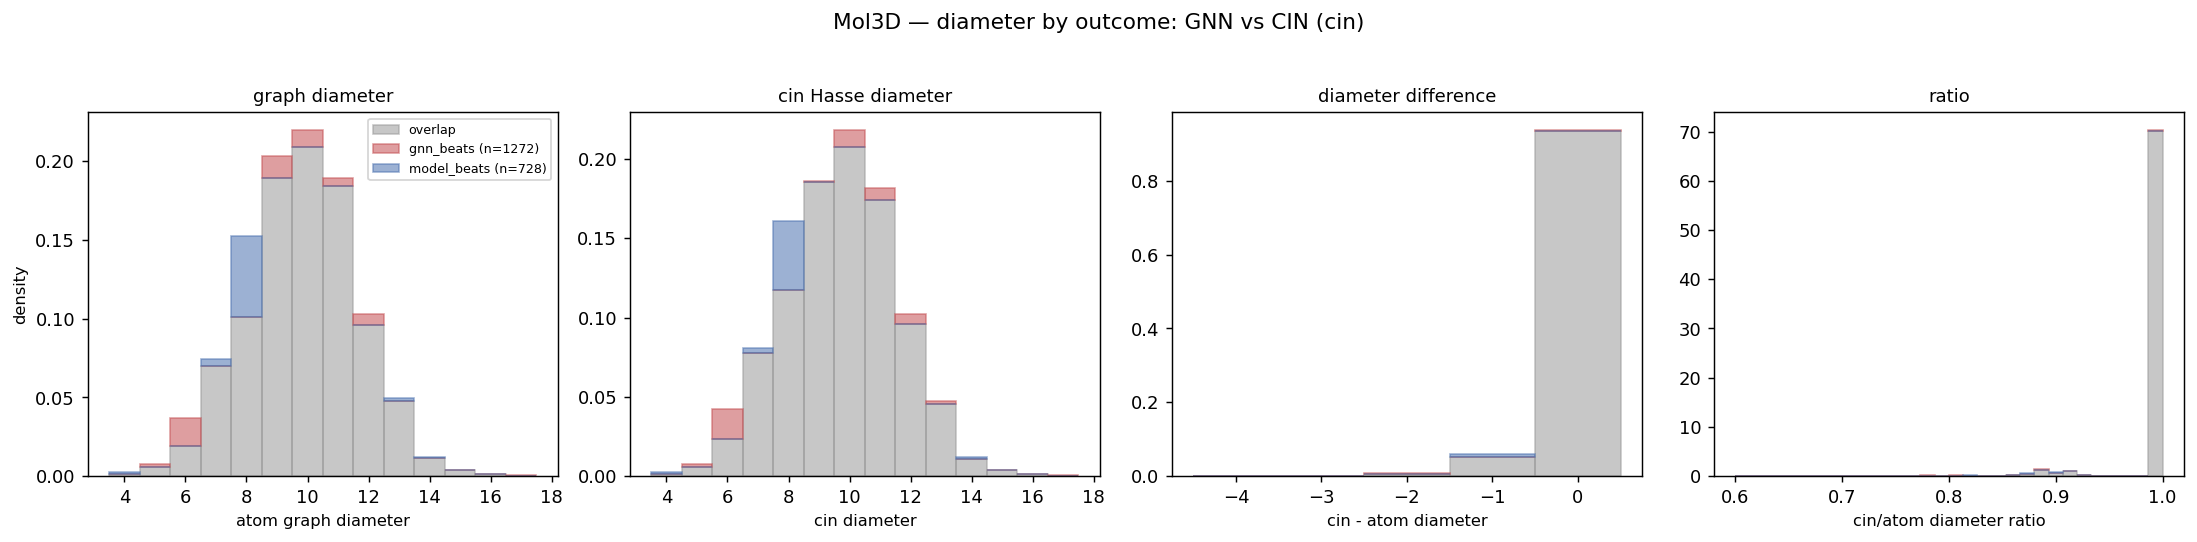

In [63]:
plot_diameter_hist_by_outcome('CIN')

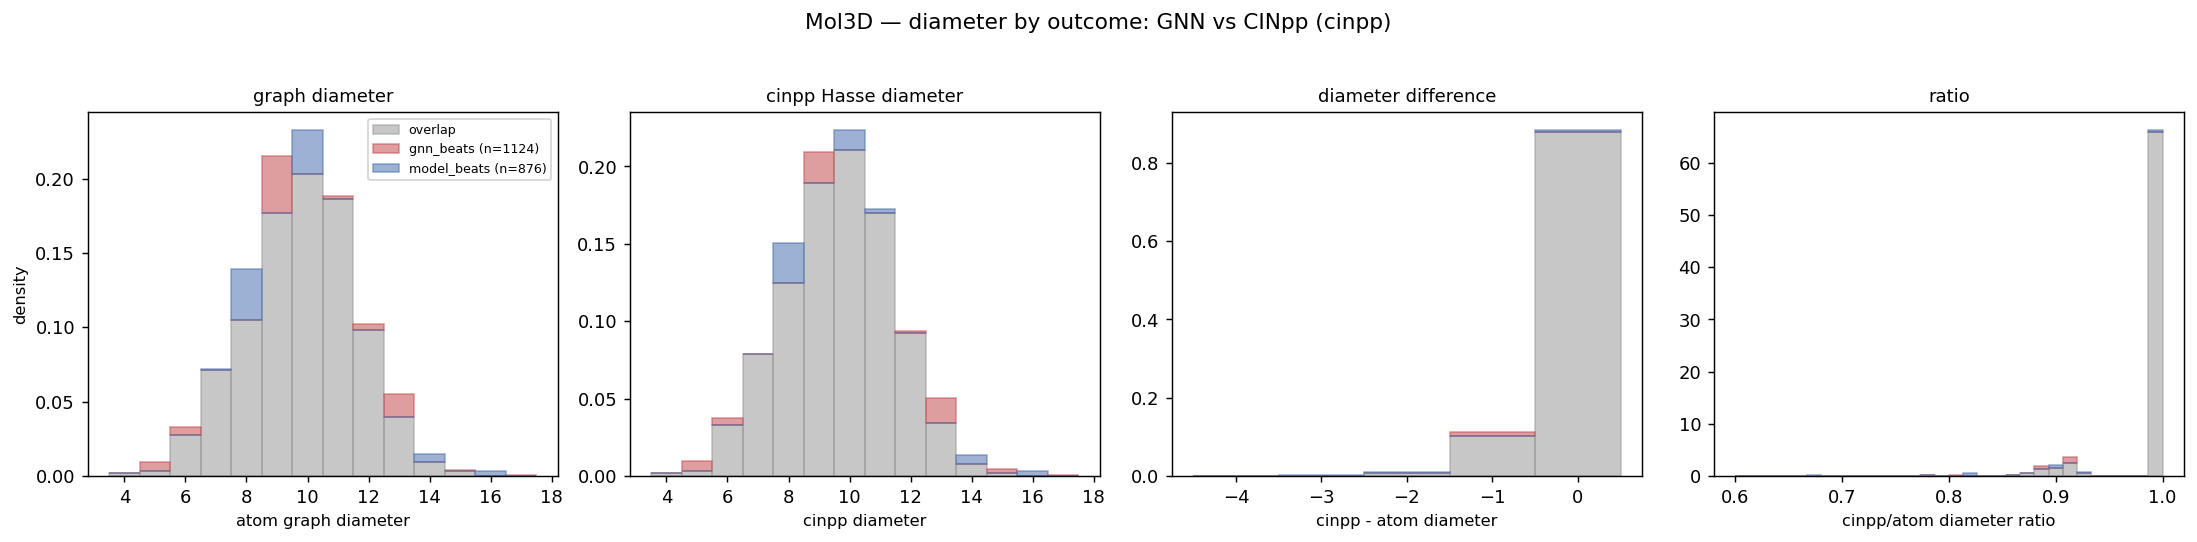

In [64]:
plot_diameter_hist_by_outcome('CINpp')